# Part I — Data Loading and Environment Setup
- Initialize analysis environment and load processed dataset.
- Automated path resolution ensures reproducibility across machines.
- Configure display options for effective data inspection.

In [25]:
# Step 1: Setup and Automatic Dataset Loading



from pathlib import Path



import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns



# Plotting & Pandas display settings

plt.style.use("seaborn-v0_8")

sns.set(font_scale=1.1)



pd.set_option("display.max_columns", 100)

pd.set_option("display.width", 140)



# Find project root by walking up until a folder containing `data/` is found

def find_project_root(marker: str = "data") -> Path:

    cwd = Path.cwd()

    for path in (cwd, *cwd.parents):

        if (path / marker).exists():

            return path

    raise FileNotFoundError(f"Could not find project root containing '{marker}' directory from {cwd}")



PROJECT_ROOT = find_project_root()



# Construct path to processed dataset inside repo

DATA_PATH = PROJECT_ROOT / "notebooks" / "model_ready_dataset.csv"



# Load dataset

df = pd.read_csv(DATA_PATH)



print(f"Loaded dataset from: {DATA_PATH}")

print("Shape:", df.shape)



df.head()


Loaded dataset from: c:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\notebooks\model_ready_dataset.csv
Shape: (327, 18)


,date,cpi_yoy,petrol_yoy,bank_rate,fx_usd,gva_growth,unemp_rate,cpi_yoy_l1,cpi_yoy_l3,cpi_yoy_l6,petrol_yoy_l1,fx_usd_l1,bank_rate_l1,gva_growth_l1,unemp_rate_l1,cpi_t1,cpi_t3,cpi_t5
0,1997-12-01,1.7,3.4,5.9375,1.6597,1.4,6.4,1.9,1.8,1.7,7.5,1.6890,5.9375,1.0,6.5,1.5,1.7,2.0
1,1998-01-01,1.5,3.2,7.2500,1.6353,1.4,6.4,1.7,1.9,2.0,3.4,1.6597,5.9375,1.4,6.4,1.6,1.8,1.7
2,1998-02-01,1.6,2.9,7.2500,1.6407,1.4,6.4,1.5,1.9,2.0,3.2,1.6353,7.2500,1.4,6.4,1.7,2.0,1.4
3,1998-03-01,1.7,3.3,7.2500,1.6620,0.8,6.3,1.6,1.7,1.8,2.9,1.6407,7.2500,1.4,6.4,1.8,1.7,1.3
4,1998-04-01,1.8,10.0,7.2500,1.6733,0.9,6.3,1.7,1.5,1.9,3.3,1.6620,7.2500,0.8,6.3,2.0,1.4,1.4


## Modeling Stack Overview
- **Stage 1 — LSTM encoder trio:** three single-output LSTMs (`t1`, `t3`, `t5`) ingest the same 18-month macro window, sharing hyperparameters while producing horizon-specific features for stacking.
- **Stage 2 — XGBoost residual heads:** three matching gradient-boosted regressors refine each horizon using the tabular drivers plus its paired LSTM prediction.
- **Deliverable:** Stage 1 forecasts double as diagnostics and stacked features, whereas Stage 2 provides the final XGBoost CPI projections used for reporting and explainability.


In [26]:
# Setup for hybrid ensemble (lookback=18) and package checks
import subprocess, sys

try:
    import torch
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "-q"])
    import torch

try:
    import xgboost as xgb
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
    import xgboost as xgb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.05)

lookback = 18

# Reuse loaded df from Cell 2
if 'df' not in globals():
    raise RuntimeError("Dataset not loaded; run the data loading cell first.")

# Ensure date
if 'date' not in df.columns:
    raise ValueError("'date' column missing; cannot split temporally.")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

train_end = '2017-12-31'
val_end = '2021-12-31'
train_mask = df['date'] <= train_end
val_mask = (df['date'] > train_end) & (df['date'] <= val_end)
test_mask = df['date'] > val_end

feature_cols = ['cpi_yoy', 'petrol_yoy', 'bank_rate', 'fx_usd', 'gva_growth', 'unemp_rate',
                'cpi_yoy_l1', 'cpi_yoy_l3', 'cpi_yoy_l6', 'petrol_yoy_l1', 'fx_usd_l1',
                'bank_rate_l1', 'gva_growth_l1', 'unemp_rate_l1']
target_cols = ['cpi_t1', 'cpi_t3', 'cpi_t5']

X_all = df[feature_cols].values
y_all = df[target_cols].values

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(X_all[train_mask.values])
X_val = scaler_X.transform(X_all[val_mask.values])
X_test = scaler_X.transform(X_all[test_mask.values])

y_train = scaler_y.fit_transform(y_all[train_mask.values])
y_val = scaler_y.transform(y_all[val_mask.values])
y_test = scaler_y.transform(y_all[test_mask.values])

print("Splits:")
print(f"Train: {train_mask.sum()} rows, Val: {val_mask.sum()} rows, Test: {test_mask.sum()} rows")
print("Scaled feature shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Scaled target shapes:", y_train.shape, y_val.shape, y_test.shape)

Splits:
Train: 241 rows, Val: 48 rows, Test: 38 rows
Scaled feature shapes: (241, 14) (48, 14) (38, 14)
Scaled target shapes: (241, 3) (48, 3) (38, 3)


## Stage 1 — LSTM Encoder Roadmap
1. **Sequence engineering:** apply the selected `lookback` (default 18 months) to transform scaled features into supervised windows that stay aligned with tabular rows.
2. **Tensor loaders:** wrap the sequences into PyTorch datasets/loaders so batch size, shuffling, and device placement are easy to tweak later.
3. **Horizon-specific encoders:** train three single-output LSTMs (`LSTM_t1`, `LSTM_t3`, `LSTM_t5`) with shared hyperparameters (hidden size 64, dropout 0.2, Adam optimizer) plus patience-based early stopping.
4. **Post-training decoding:** use the fitted scaler to inverse-transform each horizon’s predictions, exposing `lstm_pred_t*` features for downstream stacking.
5. **Diagnostics:** visualize actual vs predicted traces per split/horizon to verify stability before handing features to Stage 2.


In [27]:
# Build sequences and aligned tabular sets

def create_sequences(X, y, lb):
    X_seq, y_seq = [], []
    for i in range(len(X) - lb):
        X_seq.append(X[i:i+lb])
        y_seq.append(y[i+lb])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, lookback)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, lookback)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, lookback)

# Tabular rows aligned to sequence targets (drop first lookback rows per split)
X_train_tab = X_train[lookback:]
X_val_tab = X_val[lookback:]
X_test_tab = X_test[lookback:]

y_train_tab = y_train_seq  # aligned already

y_val_tab = y_val_seq

y_test_tab = y_test_seq

print("Sequence shapes:")
print("train", X_train_seq.shape, y_train_seq.shape)
print("val  ", X_val_seq.shape, y_val_seq.shape)
print("test ", X_test_seq.shape, y_test_seq.shape)

# Tensors and loaders
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_seq, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_seq, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32)

batch_size = 16
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size, shuffle=False)

test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

print(f"Loaders ready (batch={batch_size})")

Sequence shapes:
train (223, 18, 14) (223, 3)
val   (30, 18, 14) (30, 3)
test  (20, 18, 14) (20, 3)
Loaders ready (batch=16)


In [28]:
# Define and train horizon-specific LSTMs
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.2, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.drop1 = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.drop2 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        x = self.drop1(last)
        x = torch.relu(self.fc1(x))
        x = self.drop2(x)
        return self.fc2(x)

horizons = ['t1', 't3', 't5']
horizon_idx = {h: i for i, h in enumerate(horizons)}
input_size = X_train_seq.shape[2]
criterion = nn.MSELoss()
num_epochs = 150
patience = 15


def train_single_horizon(horizon: str, idx: int):
    model = LSTMForecaster(input_size=input_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    best_val = float('inf')
    best_state = None
    pat = 0
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            target = yb[:, idx].unsqueeze(1)
            preds = model(xb)
            loss = criterion(preds, target)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                target = yb[:, idx].unsqueeze(1)
                preds = model(xb)
                loss = criterion(preds, target)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = model.state_dict().copy()
            pat = 0
        else:
            pat += 1

        if (epoch + 1) % 20 == 0:
            print(f"[{horizon}] Epoch {epoch + 1}/{num_epochs} | Train {train_loss:.4f} | Val {val_loss:.4f}")

        if pat >= patience:
            print(f"[{horizon}] Early stopping at epoch {epoch + 1}")
            break

    if best_state is None:
        raise RuntimeError(f"No best state recorded for horizon {horizon}")

    model.load_state_dict(best_state)
    print(f"[{horizon}] Best val loss: {best_val:.4f}")
    return model, {"train": train_losses, "val": val_losses}


lstm_models = {}
lstm_histories = {}
for h in horizons:
    model, history = train_single_horizon(h, horizon_idx[h])
    lstm_models[h] = model
    lstm_histories[h] = history


[t1] Epoch 20/150 | Train 0.0167 | Val 0.0452
[t1] Epoch 40/150 | Train 0.0126 | Val 0.0534
[t1] Early stopping at epoch 43
[t1] Best val loss: 0.0367
[t3] Epoch 20/150 | Train 0.0250 | Val 0.0970
[t3] Epoch 40/150 | Train 0.0236 | Val 0.1114
[t3] Early stopping at epoch 56
[t3] Best val loss: 0.0717
[t5] Epoch 20/150 | Train 0.0340 | Val 0.2171
[t5] Epoch 40/150 | Train 0.0250 | Val 0.1779
[t5] Epoch 60/150 | Train 0.0262 | Val 0.1501
[t5] Early stopping at epoch 72
[t5] Best val loss: 0.1181


LSTM predictions ready (scaled and inverse-scaled)


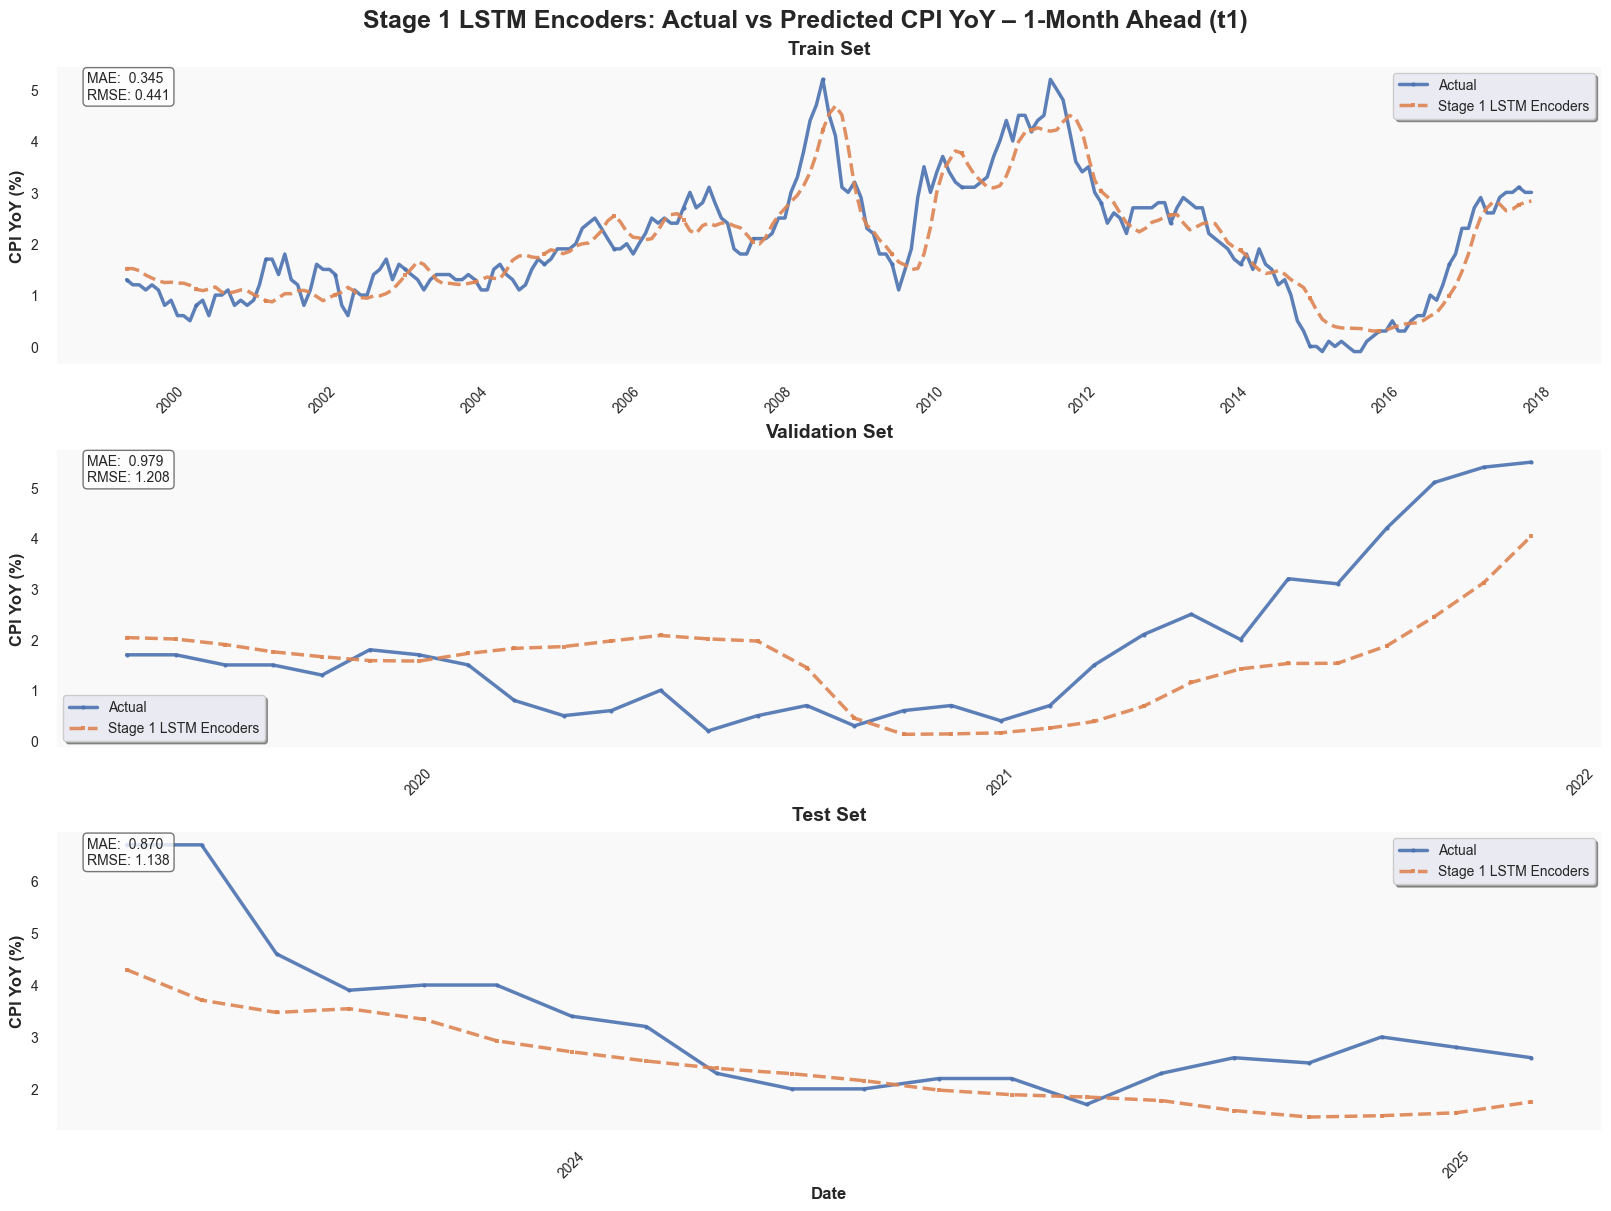

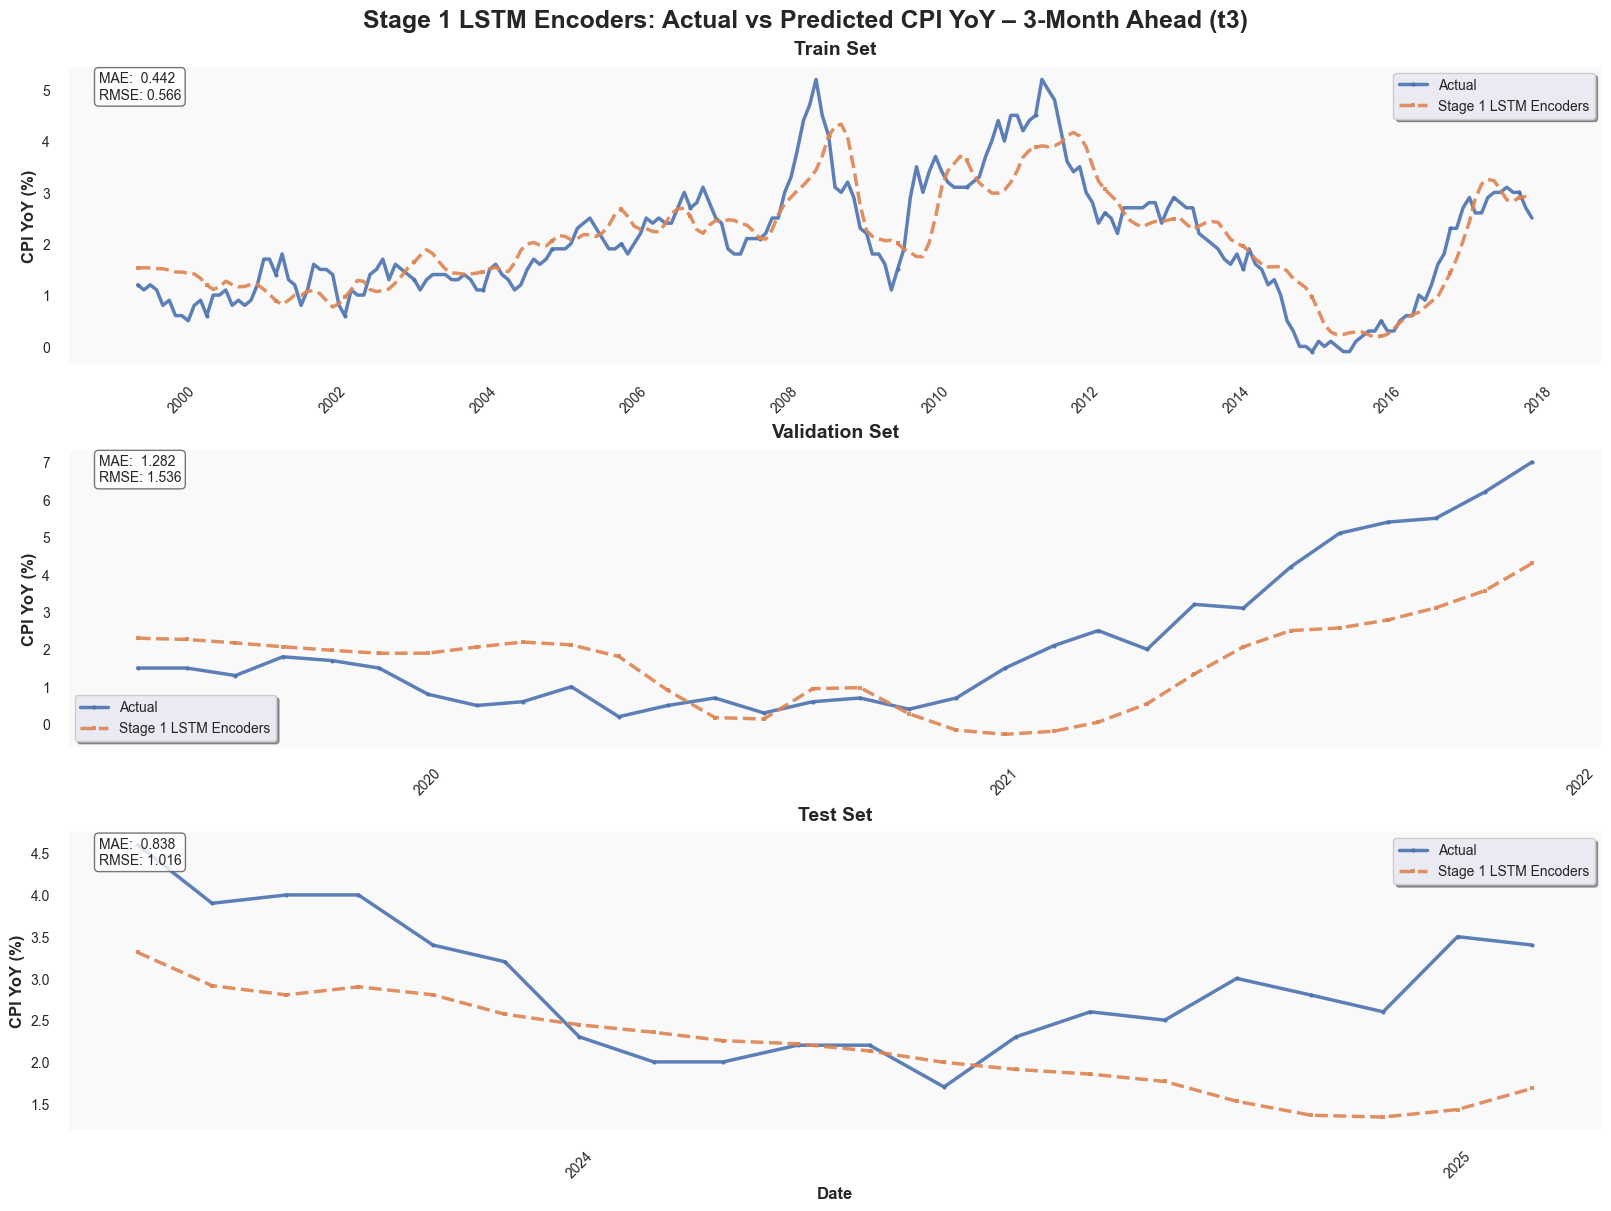

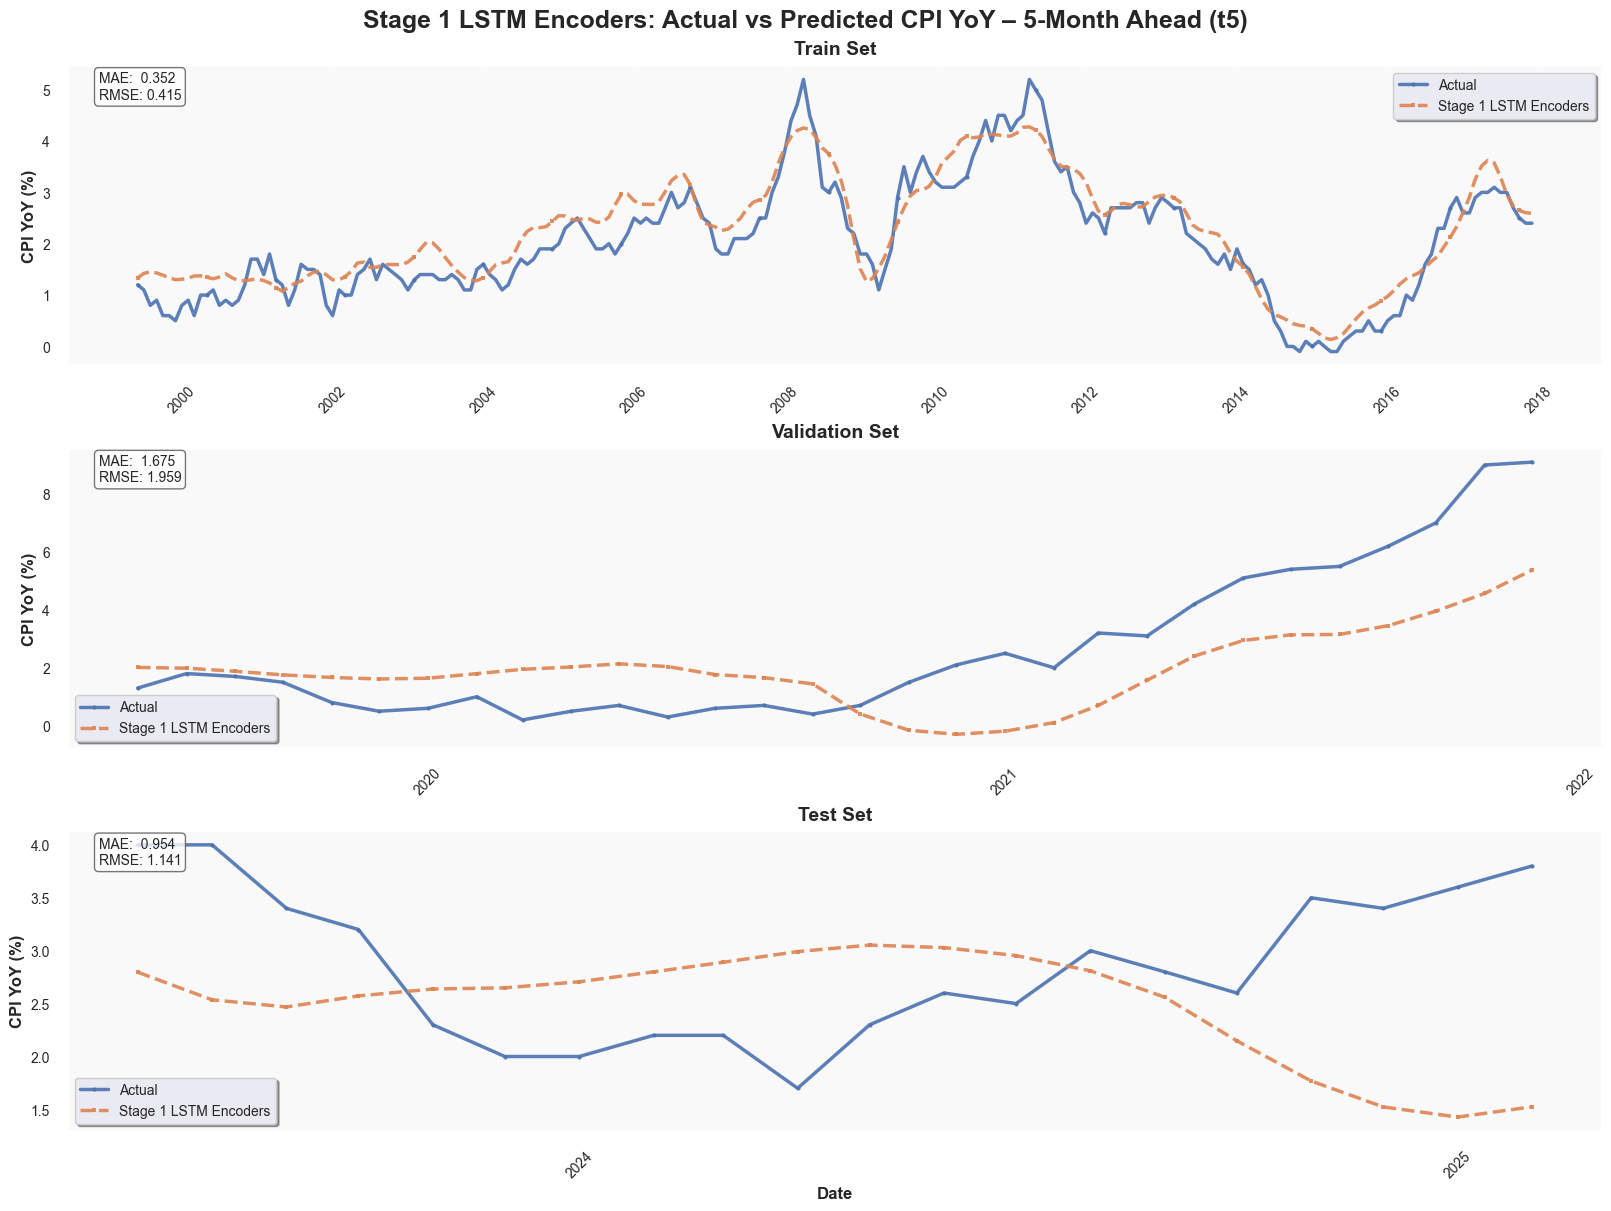

In [29]:
# LSTM predictions + clear horizon-wise plots (Train / Val / Test)

from math import sqrt
import matplotlib.dates as mdates


def predict_all_splits(model_dict, X_tensor):
    preds = []
    for h in horizons:
        mdl = model_dict[h]
        mdl.eval()
        with torch.no_grad():
            preds.append(mdl(X_tensor).cpu().numpy())
    return np.hstack(preds)


# 1) Predict with trained LSTMs (in scaled space) and inverse-transform to real CPI YoY
y_train_pred_scaled = predict_all_splits(lstm_models, X_train_tensor)
y_val_pred_scaled = predict_all_splits(lstm_models, X_val_tensor)
y_test_pred_scaled = predict_all_splits(lstm_models, X_test_tensor)

y_train_actual = scaler_y.inverse_transform(y_train_seq)
y_val_actual = scaler_y.inverse_transform(y_val_seq)
y_test_actual = scaler_y.inverse_transform(y_test_seq)

y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled)
y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)

print("LSTM predictions ready (scaled and inverse-scaled)")

# 2) Prepare split data and aligned dates (drop first lookback rows for sequences)
split_data = {
    "Train": (
        y_train_actual,
        y_train_pred,
        df[train_mask]["date"].values[lookback:]
    ),
    "Validation": (
        y_val_actual,
        y_val_pred,
        df[val_mask]["date"].values[lookback:]
    ),
    "Test": (
        y_test_actual,
        y_test_pred,
        df[test_mask]["date"].values[lookback:]
    ),
}

# (index in target arrays, label for title)
horizon_info = [
    (0, "1-Month Ahead (t1)"),
    (1, "3-Month Ahead (t3)"),
    (2, "5-Month Ahead (t5)"),
]

# 3) Plot: one figure per horizon, with 3 rows (Train / Val / Test)
for h_idx, h_label in horizon_info:
    fig, axes = plt.subplots(
        nrows=3,
        ncols=1,
        figsize=(16, 12),
        constrained_layout=True
    )
    fig.suptitle(
        f"Stage 1 LSTM Encoders: Actual vs Predicted CPI YoY – {h_label}",
        fontsize=18,
        fontweight="bold"
    )

    # Ensure axes is iterable
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    for ax, (split_name, (y_actual_all, y_pred_all, dates)) in zip(axes, split_data.items()):
        # Select this horizon
        actual_vals = y_actual_all[:, h_idx]
        pred_vals   = y_pred_all[:, h_idx]

        # Time series plot: Actual vs Predicted
        ax.plot(
            dates,
            actual_vals,
            label="Actual",
            linewidth=2.5,
            marker="o",
            markersize=3,
            markevery=max(1, len(dates) // 20),
            alpha=0.9,
        )
        ax.plot(
            dates,
            pred_vals,
            label="Stage 1 LSTM Encoders",
            linewidth=2.5,
            linestyle="--",
            marker="s",
            markersize=3,
            markevery=max(1, len(dates) // 20),
            alpha=0.9,
        )

        # Titles & labels
        ax.set_title(f"{split_name} Set", fontsize=14, fontweight="bold", pad=8)
        ax.set_ylabel("CPI YoY (%)", fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.8)
        ax.tick_params(axis="x", rotation=45, labelsize=10)
        ax.tick_params(axis="y", labelsize=10)
        ax.set_facecolor("#F9F9F9")

        # Less crowded time axis
        if split_name == "Train":
            # Long period → tick every 2 years
            ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        else:
            # Shorter periods → yearly ticks
            ax.xaxis.set_major_locator(mdates.YearLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

        # Metrics: MAE and RMSE for this split + horizon
        mae_val = mean_absolute_error(actual_vals, pred_vals)
        rmse_val = sqrt(mean_squared_error(actual_vals, pred_vals))

        ax.text(
            0.02,
            0.98,
            f"MAE:  {mae_val:.3f}\nRMSE: {rmse_val:.3f}",
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment="top",
            bbox=dict(
                boxstyle="round",
                facecolor="white",
                alpha=0.8,
                edgecolor="#555555",
            ),
        )

        ax.legend(loc="best", frameon=True, shadow=True, fontsize=10)

    axes[-1].set_xlabel("Date", fontsize=12, fontweight="bold")
    plt.show()


## Stage 2 — XGBoost Residual Stack Roadmap
1. **Stacked feature matrix:** concatenate the tabular drivers with the Stage 1 outputs (`lstm_pred_t1`, `lstm_pred_t3`, `lstm_pred_t5`) so each booster sees both macro context and its paired sequential signal.
2. **Three dedicated boosters:** train `XGB_t1`, `XGB_t3`, and `XGB_t5` with identical hyperparameters (learning rate 0.03, max_depth 6, early stopping on validation) to preserve comparability while allowing horizon-specific residual learning.
3. **Prediction decoding:** inverse-transform the stacked outputs back to CPI YoY units to obtain Stage 2 XGBoost forecasts per split and horizon.
4. **Downstream usage:** feed the Stage 2 XGBoost predictions into evaluation routines and optional SHAP/explainability steps without changing the Stage 2 structure.


In [30]:
# Horizon bookkeeping for stacked learners
horizons = ['t1', 't3', 't5']
horizon_idx = {h: i for i, h in enumerate(horizons)}

In [ ]:
# Stacking features include LSTM predictions
stack_train_X = np.hstack([X_train_tab, y_train_pred_scaled])
stack_val_X = np.hstack([X_val_tab, y_val_pred_scaled])
stack_test_X = np.hstack([X_test_tab, y_test_pred_scaled])

xgb_params_stack = dict(
    learning_rate=0.03,
    max_depth=6,
    n_estimators=500,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='reg:squarederror',
    tree_method='hist'
)

hybrid_models = {}
for h in horizons:
    idx = horizon_idx[h]
    dtrain = xgb.DMatrix(stack_train_X, label=y_train_tab[:, idx])
    dval = xgb.DMatrix(stack_val_X, label=y_val_tab[:, idx])
    model = xgb.train(
        params=xgb_params_stack,
        dtrain=dtrain,
        num_boost_round=2000,
        evals=[(dval, 'val')],
        early_stopping_rounds=75,
        verbose_eval=False
    )
    hybrid_models[h] = model

# Predict
stack_train_pred_scaled = np.column_stack([
    hybrid_models[h].predict(xgb.DMatrix(stack_train_X)) for h in horizons
])
stack_val_pred_scaled = np.column_stack([
    hybrid_models[h].predict(xgb.DMatrix(stack_val_X)) for h in horizons
])
stack_test_pred_scaled = np.column_stack([
    hybrid_models[h].predict(xgb.DMatrix(stack_test_X)) for h in horizons
])

hybrid_train = scaler_y.inverse_transform(stack_train_pred_scaled)
hybrid_val = scaler_y.inverse_transform(stack_val_pred_scaled)
hybrid_test = scaler_y.inverse_transform(stack_test_pred_scaled)

print("Stage 2 XGBoost stack trained")


c:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\.venv\Lib\site-packages\xgboost\callback.py:386: UserWarning: [00:49:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()
c:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\.venv\Lib\site-packages\xgboost\callback.py:386: UserWarning: [00:49:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()


Hybrid stacking models trained


## 5. Evaluation Protocol
- Compute MAE, RMSE, R² per component/split/horizon.
- Report results in tabular format for easy comparison.
- Structure: Stage 1 LSTM encoders vs Stage 2 XGBoost stack × Splits (Train/Val/Test) × Horizons (t1/t3/t5).


In [ ]:
def metrics_block(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2': r2_score(y_true, y_pred)
    }

truth = {
    'train': (y_train_actual, {'encoder': y_train_pred, 'hybrid': hybrid_train}),
    'val':   (y_val_actual,   {'encoder': y_val_pred,   'hybrid': hybrid_val}),
    'test':  (y_test_actual,  {'encoder': y_test_pred,  'hybrid': hybrid_test})
}

model_labels = {
    'encoder': 'Stage 1 LSTM Encoders',
    'hybrid': 'Stage 2 XGBoost Stack'
}
splits = ['train','val','test']
horizons = ['t1','t3','t5']

results = {m:{s:[] for s in splits} for m in model_labels}

for s in splits:
    yt, yps = truth[s]
    for m in model_labels:
        res = [metrics_block(yt[:, i], yps[m][:, i]) for i in range(3)]
        results[m][s] = res

# Pretty print table
print("="*90)
print("MAE / RMSE / R2 per component, split, horizon")
for m, label in model_labels.items():
    print(f"\n[{label}]")
    for s in splits:
        vals = results[m][s]
        line = " | ".join([f"{h}: MAE {v['mae']:.3f} RMSE {v['rmse']:.3f} R2 {v['r2']:.3f}" for h,v in zip(horizons, vals)])
        print(f"{s:<5} -> {line}")
print("="*90)


MAE / RMSE / R2 per component, split, horizon

[Stage 1 LSTM Encoders]
train -> t1: MAE 0.345 RMSE 0.441 R2 0.854 | t3: MAE 0.442 RMSE 0.566 R2 0.759 | t5: MAE 0.352 RMSE 0.415 R2 0.870
val   -> t1: MAE 0.979 RMSE 1.208 R2 0.341 | t3: MAE 1.282 RMSE 1.536 R2 0.353 | t5: MAE 1.675 RMSE 1.959 R2 0.415
test  -> t1: MAE 0.870 RMSE 1.138 R2 0.325 | t3: MAE 0.838 RMSE 1.016 R2 -0.668 | t5: MAE 0.954 RMSE 1.141 R2 -1.673

[Stage 2 Hybrid Model]
train -> t1: MAE 0.008 RMSE 0.010 R2 1.000 | t3: MAE 0.009 RMSE 0.012 R2 1.000 | t5: MAE 0.011 RMSE 0.015 R2 1.000
val   -> t1: MAE 0.501 RMSE 0.664 R2 0.801 | t3: MAE 1.029 RMSE 1.378 R2 0.479 | t5: MAE 1.892 RMSE 2.260 R2 0.221
test  -> t1: MAE 0.799 RMSE 1.269 R2 0.161 | t3: MAE 0.784 RMSE 0.910 R2 -0.339 | t5: MAE 0.818 RMSE 1.013 R2 -1.106


### Predicted vs Actual Grids (Stage 1 vs Stage 2)
- Calibration assessment via scatter plots across splits and horizons.
- Diagonal reference: perfect agreement; dispersion reflects residual error.
- Side-by-side grids contrast Stage 1 LSTM encoders with the Stage 2 XGBoost learners for rapid visual comparison.


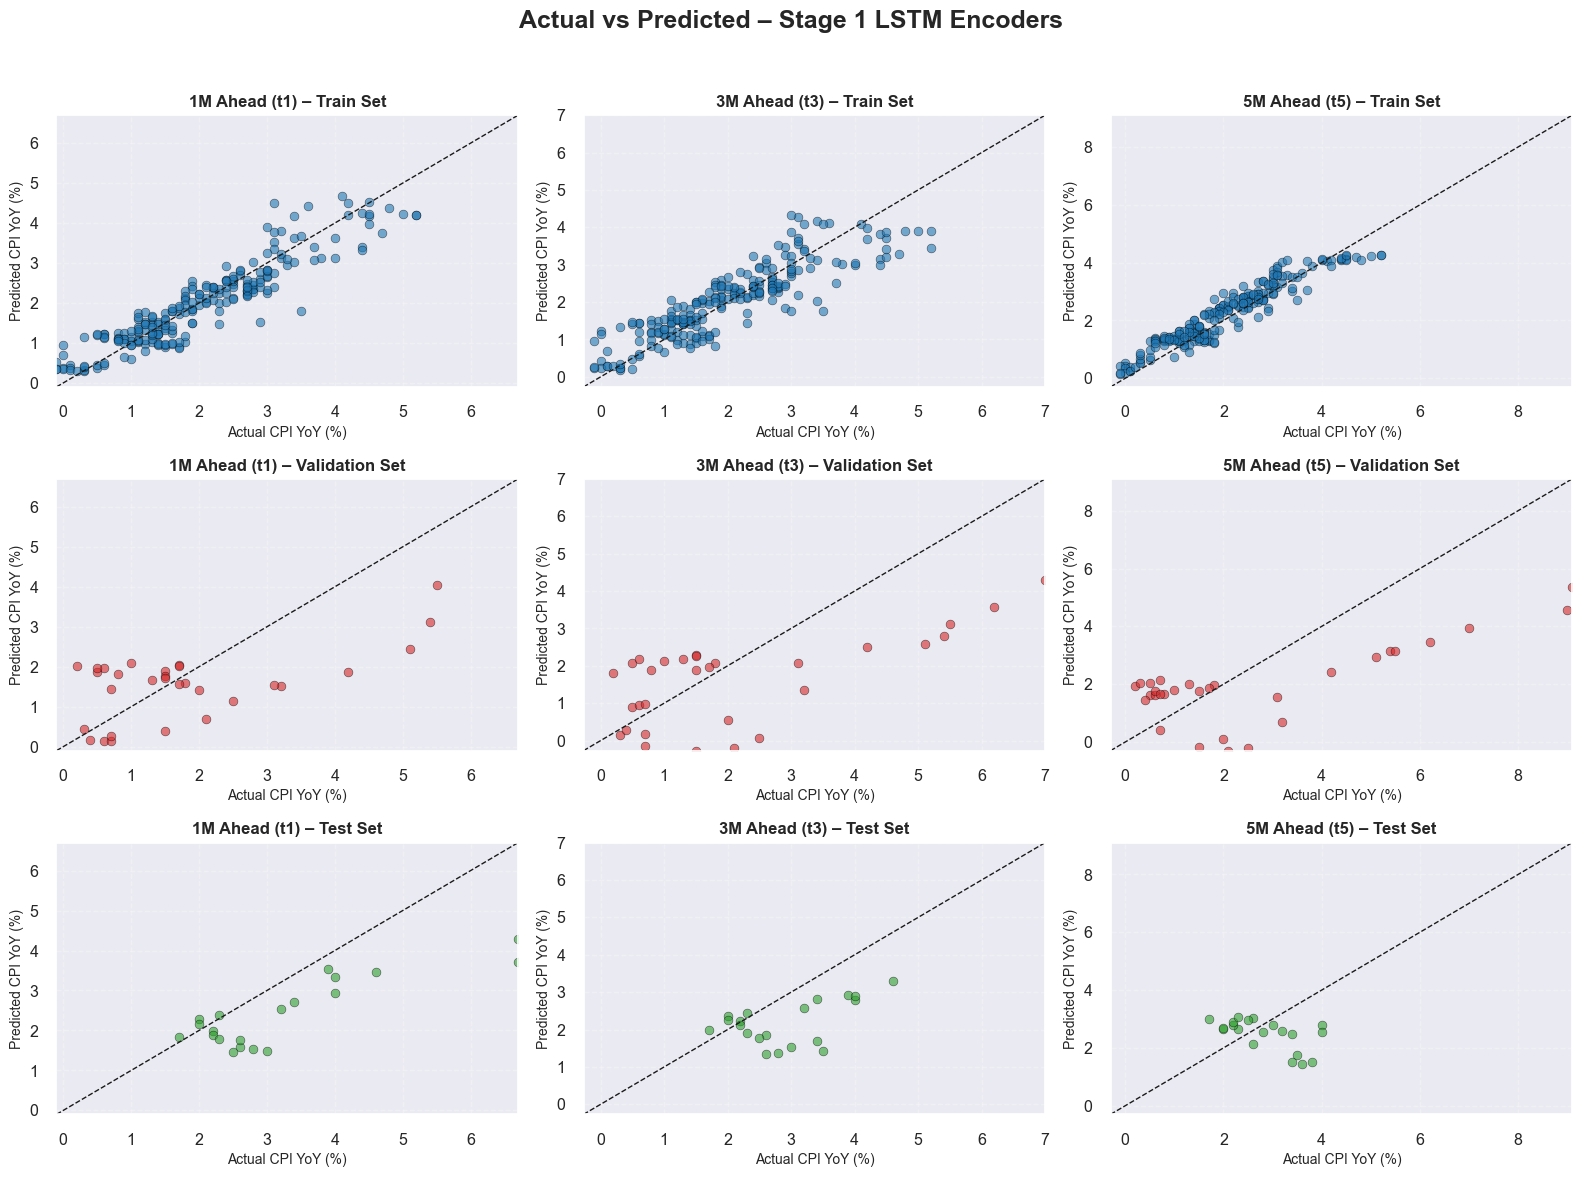

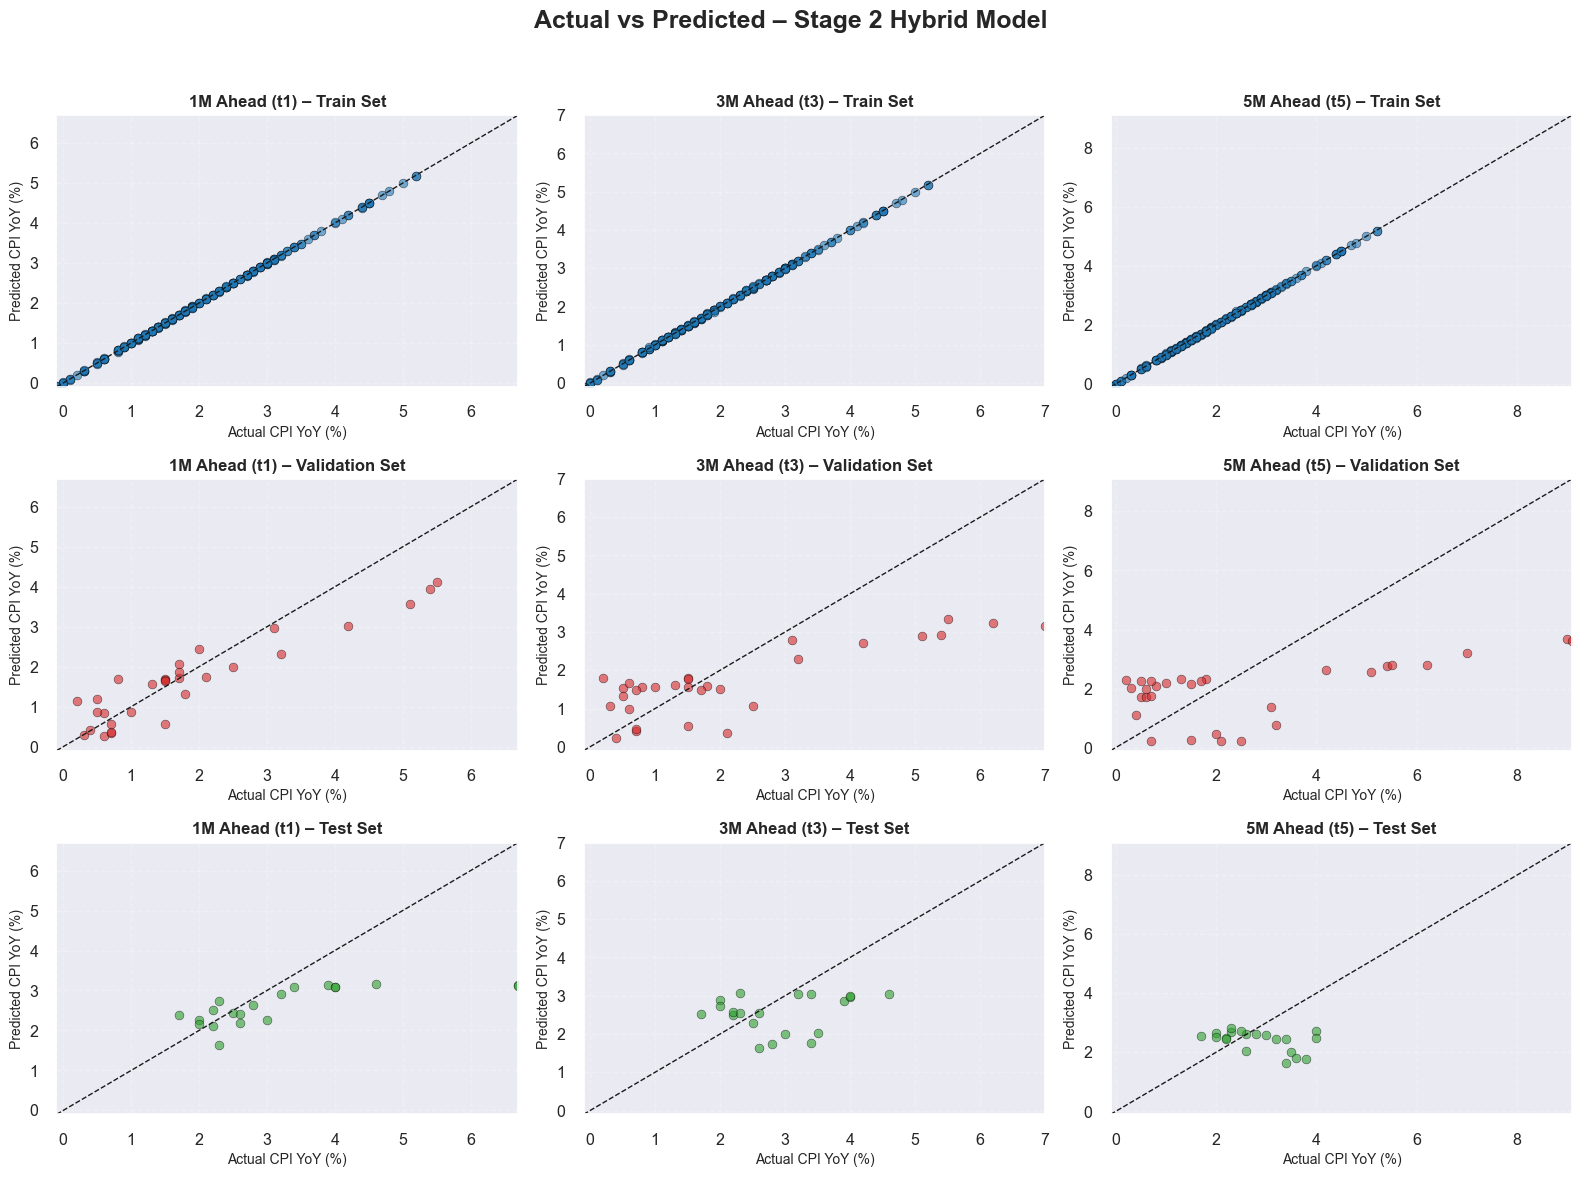

In [ ]:
# Build dict for plotting then render grids
preds_for_plot = {
    'encoder': {
        'label': 'Stage 1 LSTM Encoders',
        'preds': {
            'train': y_train_pred,
            'val':   y_val_pred,
            'test':  y_test_pred,
        },
    },
    'hybrid': {
        'label': 'Stage 2 XGBoost Stack',
        'preds': {
            'train': hybrid_train,
            'val':   hybrid_val,
            'test':  hybrid_test,
        },
    },
}

def plot_grid_clean(model_key, model_info, title_prefix):
    horizons = ['t1', 't3', 't5']
    horizon_labels = ['1M Ahead (t1)', '3M Ahead (t3)', '5M Ahead (t5)']
    splits = ['train', 'val', 'test']
    split_labels = ['Train Set', 'Validation Set', 'Test Set']
    colors = ['#1f77b4', '#d62728', '#2ca02c']  # blue, red, green

    # True values dictionary (already inverse scaled)
    split_true = {
        'train': y_train_actual,
        'val':   y_val_actual,
        'test':  y_test_actual
    }

    preds = model_info['preds']

    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    fig.suptitle(f"{title_prefix} – {model_info['label']}", fontsize=18, fontweight='bold')

    for col, (hidx, hlabel) in enumerate(zip([0,1,2], horizon_labels)):
        # Determine common axis limits for this horizon
        all_true = np.concatenate([split_true[s][:, hidx] for s in splits])
        all_pred = np.concatenate([preds[s][:, hidx] for s in splits])
        minv = min(all_true.min(), all_pred.min())
        maxv = max(all_true.max(), all_pred.max())

        for row, (s, slabel, color) in enumerate(zip(splits, split_labels, colors)):
            ax = axes[row, col]

            yt = split_true[s][:, hidx]
            yp = preds[s][:, hidx]

            # Scatter plot
            ax.scatter(yt, yp, alpha=0.6, s=40, color=color, edgecolor='black', linewidth=0.4)

            # Diagonal reference line
            ax.plot([minv, maxv], [minv, maxv], 'k--', linewidth=1)

            # Titles & labels
            ax.set_title(f"{hlabel} – {slabel}", fontsize=12, fontweight='bold')
            ax.set_xlabel("Actual CPI YoY (%)", fontsize=10)
            ax.set_ylabel("Predicted CPI YoY (%)", fontsize=10)

            # Limits for consistent comparison
            ax.set_xlim(minv, maxv)
            ax.set_ylim(minv, maxv)

            ax.grid(alpha=0.25, linestyle='--')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


for key in ['encoder', 'hybrid']:
    plot_grid_clean(key, preds_for_plot[key], title_prefix="Actual vs Predicted")


### Transition — From Stage 1 Encoders to Stage 2 XGBoost
The calibrated horizon-specific LSTM trajectories now serve two purposes: (1) standalone diagnostics reported above, and (2) stacked inputs that augment the macro-tabular drivers. The next section trains XGBoost residual learners on this combined representation, yielding the final Stage 2 XGBoost forecasts.


# Part III — Stage 2 XGBoost Stack
- Stage 2 XGBoost stack = Stage 1 LSTM sequences feeding horizon-specific XGBoost residual learners (stacked features).
- Visuals highlight alignment between the sequential encoders and the final stacked predictions.
- Benchmark performance across all splits and horizons for rigorous comparison.


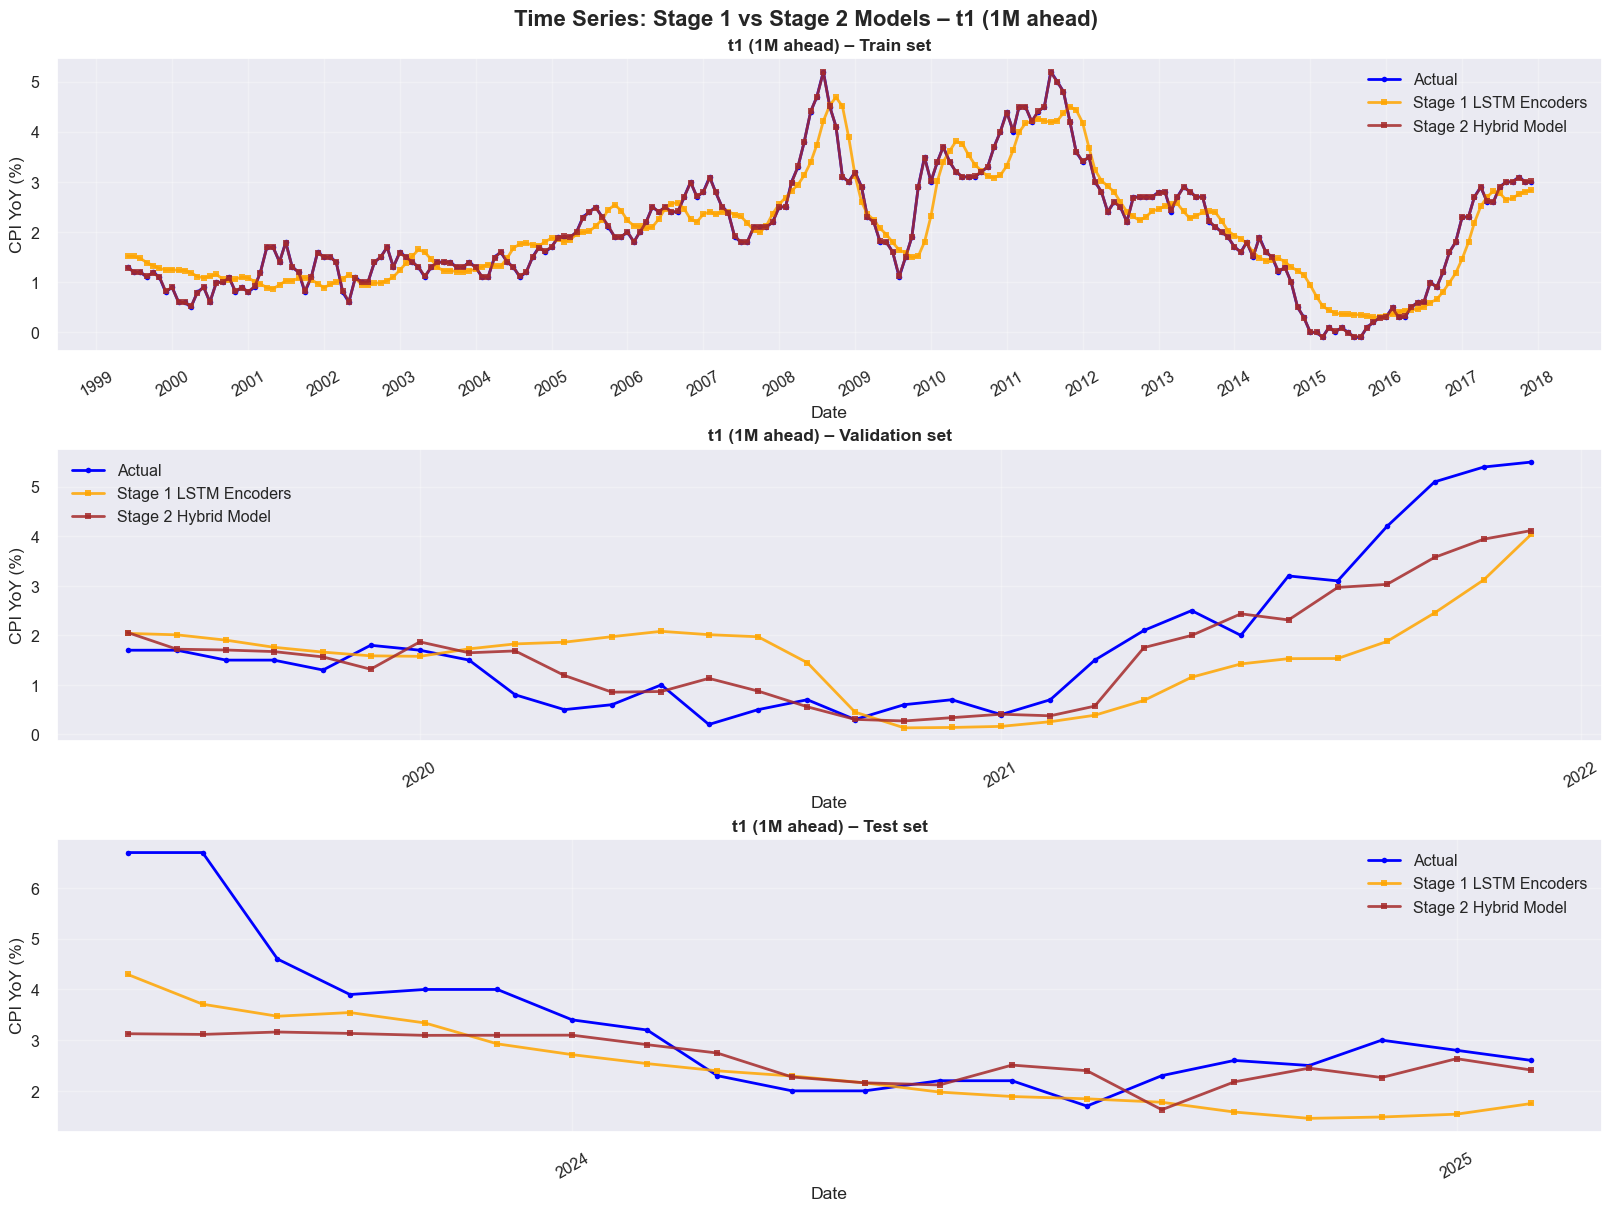

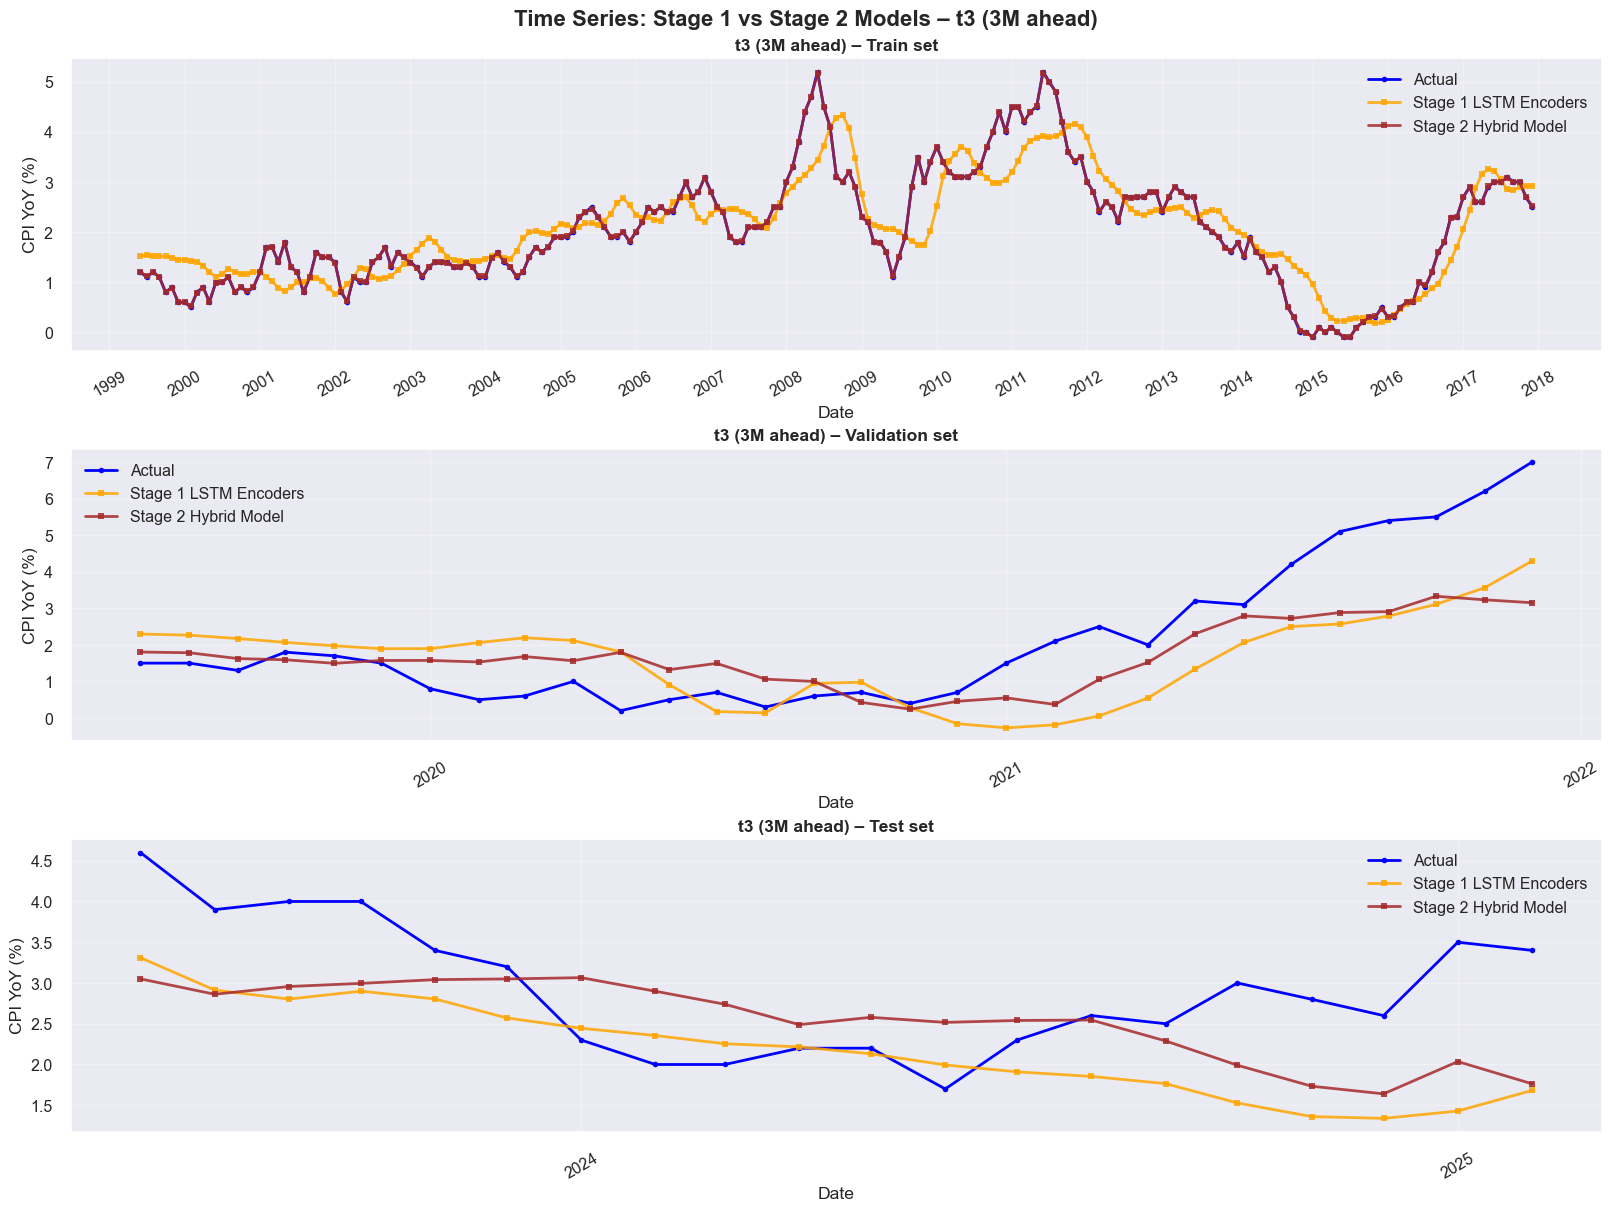

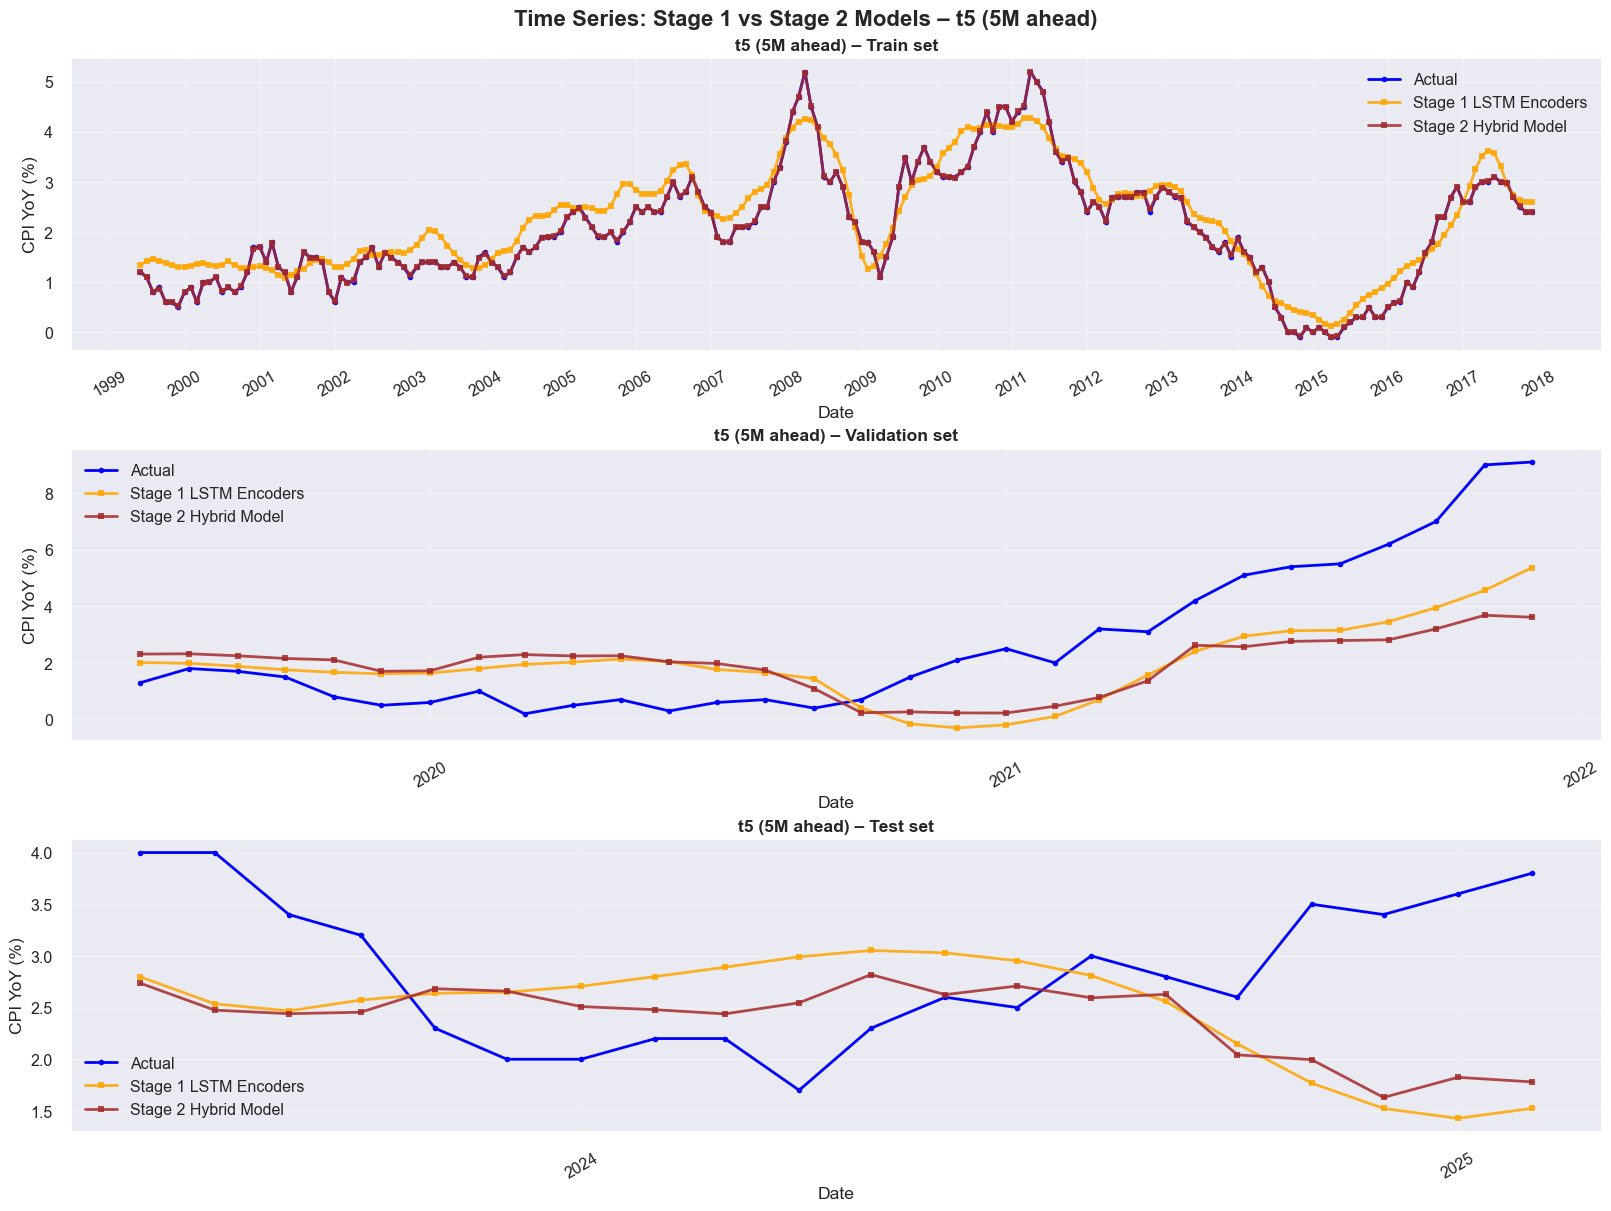

In [ ]:
import matplotlib.dates as mdates

def plot_ts_all_horizons(title_prefix):
    splits = ['train', 'val', 'test']
    split_labels = {'train': 'Train', 'val': 'Validation', 'test': 'Test'}
    model_colors = {'Stage 1 LSTM Encoders': 'orange', 'Stage 2 XGBoost Stack': 'brown'}
    horizon_indices = [0, 1, 2]
    horizon_labels = ['t1 (1M ahead)', 't3 (3M ahead)', 't5 (5M ahead)']

    # Prepare dates once
    dates_ts = {
        'train': df[train_mask]['date'].values[lookback:],
        'val':   df[val_mask]['date'].values[lookback:],
        'test':  df[test_mask]['date'].values[lookback:],
    }

    for idx, hlabel in zip(horizon_indices, horizon_labels):
        # Actual series for this horizon
        actual_ts = {
            'train': y_train_actual[:, idx],
            'val':   y_val_actual[:, idx],
            'test':  y_test_actual[:, idx],
        }

        # Predictions for this horizon
        pred_ts = {
            'Stage 1 LSTM Encoders': {
                'train': y_train_pred[:, idx],
                'val':   y_val_pred[:, idx],
                'test':  y_test_pred[:, idx],
            },
            'Stage 2 XGBoost Stack': {
                'train': hybrid_train[:, idx],
                'val':   hybrid_val[:, idx],
                'test':  hybrid_test[:, idx],
            },
        }

        # Figure for this horizon: 3 rows (Train/Val/Test)
        fig, axes = plt.subplots(3, 1, figsize=(16, 12), constrained_layout=True)
        fig.suptitle(f"{title_prefix} – {hlabel}", fontsize=16, fontweight='bold')

        for i, split in enumerate(splits):
            ax = axes[i]
            dates = dates_ts[split]

            ax.plot(
                dates,
                actual_ts[split],
                'o-',
                label='Actual',
                color='blue',
                linewidth=2,
                markersize=4,
            )

            for model_label, color in model_colors.items():
                ax.plot(
                    dates,
                    pred_ts[model_label][split],
                    's-',
                    label=model_label,
                    color=color,
                    linewidth=2,
                    markersize=4,
                    alpha=0.85,
                )

            ax.set_title(f"{hlabel} – {split_labels[split]} set", fontweight='bold')
            ax.set_xlabel('Date')
            ax.set_ylabel('CPI YoY (%)')
            ax.grid(alpha=0.3)
            ax.legend()
            ax.tick_params(axis='x', rotation=30)

            # Clean yearly x-axis
            ax.xaxis.set_major_locator(mdates.YearLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

        plt.show()


## Call once to plot t1, t3, t5 (3 figures total)
plot_ts_all_horizons(title_prefix='Time Series: Stage 1 vs Stage 2 Models')


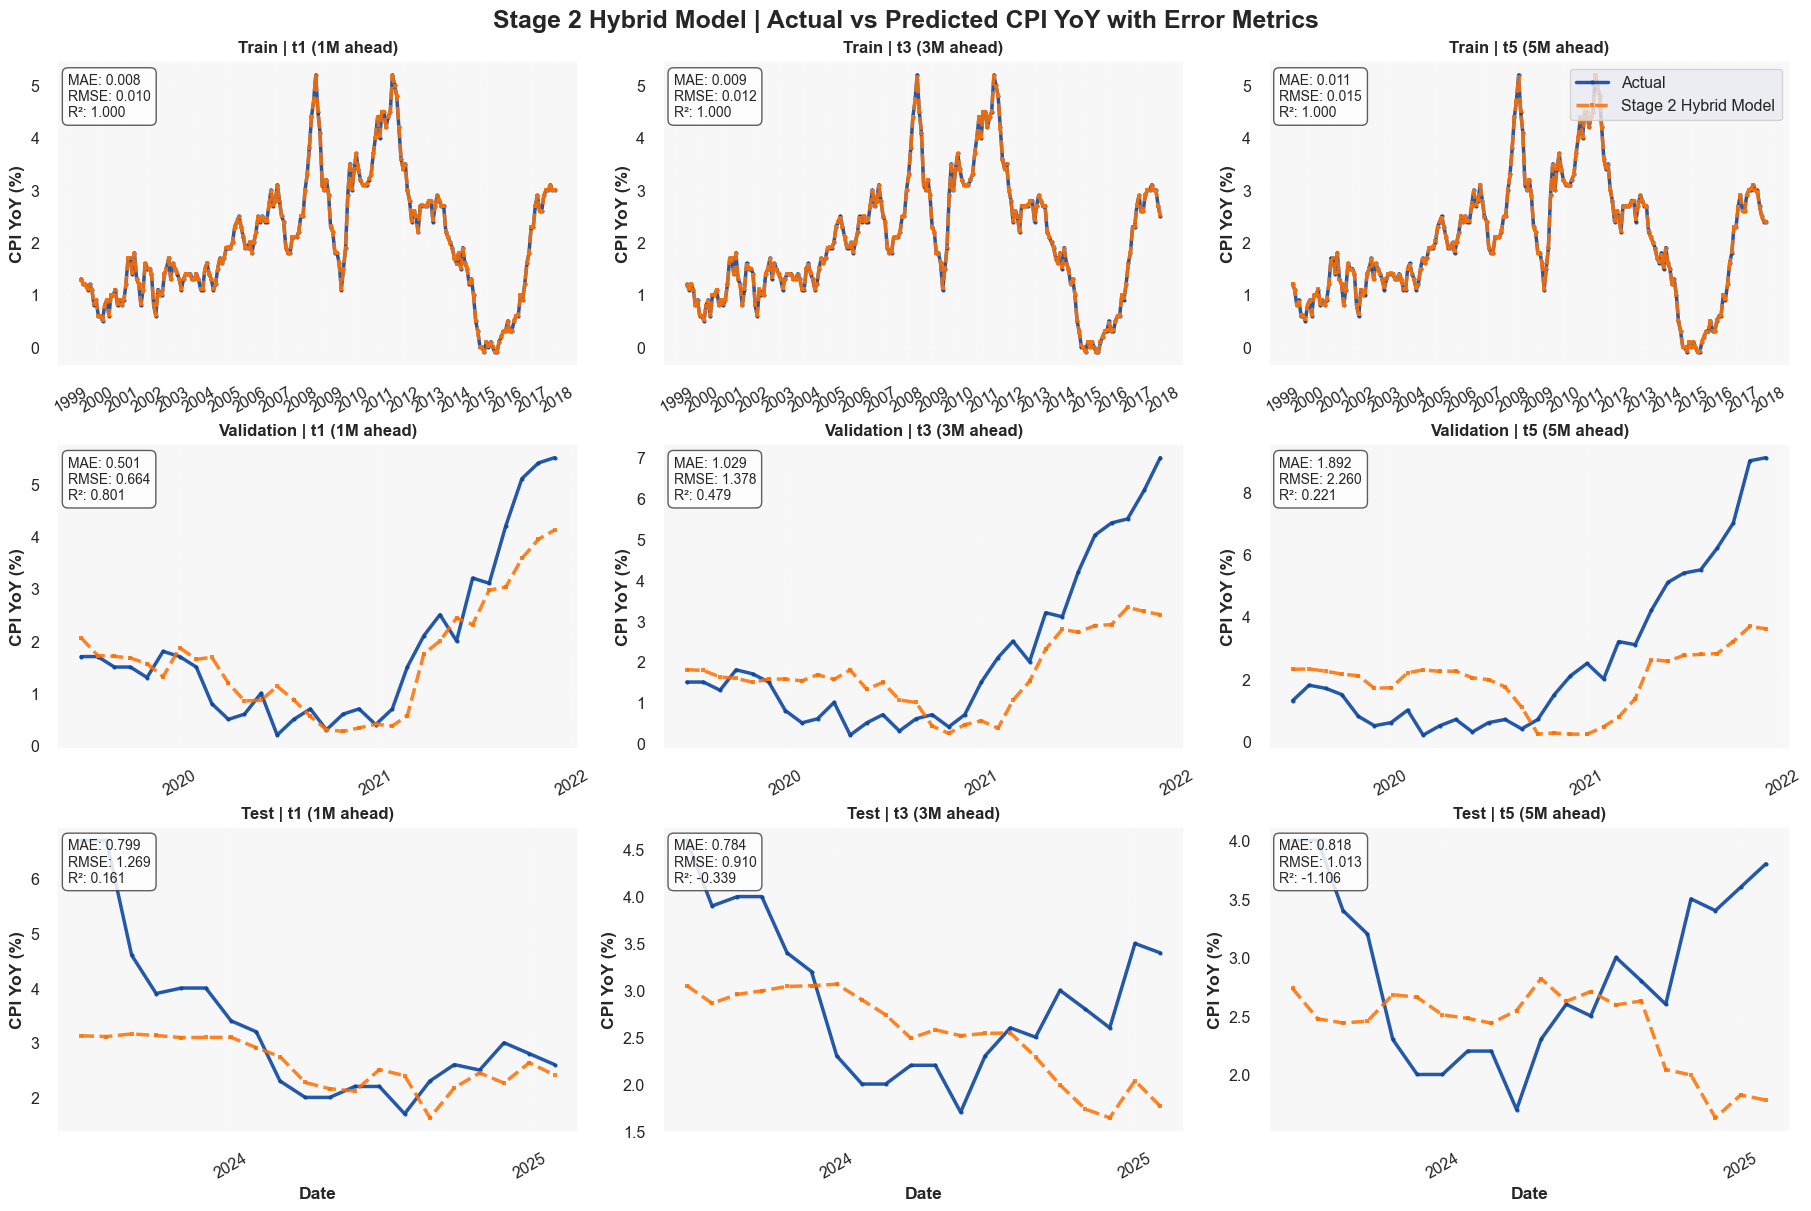

In [ ]:
# Stage 2 XGBoost stack only: Train/Val/Test line charts with metrics
import matplotlib.dates as mdates
from math import sqrt

splits = ['train', 'val', 'test']
split_labels = {'train': 'Train', 'val': 'Validation', 'test': 'Test'}
horizon_info = [(0, 't1 (1M ahead)'), (1, 't3 (3M ahead)'), (2, 't5 (5M ahead)')]

split_truth = {
    'train': y_train_actual,
    'val': y_val_actual,
    'test': y_test_actual,
}

split_pred = {
    'train': hybrid_train,
    'val': hybrid_val,
    'test': hybrid_test,
}

split_dates = {
    'train': df[train_mask]['date'].values[lookback:],
    'val': df[val_mask]['date'].values[lookback:],
    'test': df[test_mask]['date'].values[lookback:],
}

fig, axes = plt.subplots(len(splits), len(horizon_info), figsize=(18, 12), constrained_layout=True)
fig.suptitle('Stage 2 XGBoost Stack | Actual vs Predicted CPI YoY with Error Metrics', fontsize=18, fontweight='bold')

for row, split in enumerate(splits):
    dates = split_dates[split]
    yt = split_truth[split]
    yp = split_pred[split]
    for col, (idx, horizon_label) in enumerate(horizon_info):
        ax = axes[row, col]
        actual_series = yt[:, idx]
        pred_series = yp[:, idx]

        ax.plot(dates, actual_series, color='#0D47A1', linewidth=2.5, label='Actual', marker='o', markersize=3, alpha=0.9)
        ax.plot(dates, pred_series, color='#FF6F00', linewidth=2.5, linestyle='--', label='Stage 2 XGBoost Stack', marker='s', markersize=3, alpha=0.85)

        ax.set_title(f"{split_labels[split]} | {horizon_label}", fontweight='bold', fontsize=12)
        ax.set_ylabel('CPI YoY (%)', fontweight='bold')
        ax.grid(alpha=0.25, linestyle='--')
        ax.set_facecolor('#F7F7F7')
        ax.tick_params(axis='x', rotation=30)
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

        mae_val = mean_absolute_error(actual_series, pred_series)
        rmse_val = sqrt(mean_squared_error(actual_series, pred_series))
        r2_val = r2_score(actual_series, pred_series)
        ax.text(
            0.02,
            0.96,
            f"MAE: {mae_val:.3f}\nRMSE: {rmse_val:.3f}\nR²: {r2_val:.3f}",
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='#424242'),
        )

        if row == 0 and col == len(horizon_info) - 1:
            ax.legend(loc='upper right', frameon=True)

# Label x-axis only on bottom row
for col in range(len(horizon_info)):
    axes[-1, col].set_xlabel('Date', fontweight='bold')

plt.show()


In [36]:
# Run hybrid stacking pipeline and save artifacts

import sys, yaml, importlib
from pathlib import Path

# Ensure repo root on path for `src` imports
try:
    from pathlib import Path as _P
    sys.path.append(str(PROJECT_ROOT))
except NameError:
    sys.path.append(str(Path.cwd().parents[0]))

# Reload modules to pick up any source changes during this session
import src.models.xgboost_model as _xgm
import src.models.ensemble as _ens
importlib.reload(_xgm)
importlib.reload(_ens)
from src.models.ensemble import train_hybrid_b as train_hybrid_model

# Resolve paths relative to project root if available
try:
    ROOT = PROJECT_ROOT
except NameError:
    ROOT = Path.cwd().parents[0]

CONFIG_PATH = ROOT / "configs" / "hybrid.yaml"
RESULTS_DIR = ROOT / "results" / "hybrid"

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

artifacts = train_hybrid_model(config, RESULTS_DIR)
print("Hybrid stacking pipeline complete. Artifacts saved to:", RESULTS_DIR)

Hybrid stacking pipeline complete. Artifacts saved to: c:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\results\hybrid
